In [1]:
%load_ext autoreload
%autoreload 2

import cv2
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

from config import (
    CONTENT_SCALE,
    DRAWING_BBOX,
    TEMPLATES_DIR, OUTPUT_DIR,
)
from utils import correct_photo, image_rect_from_svg

# --- что обрабатываем ---
CHAR_ID = "003"
STEM = "003_test3"

# --- derived ---
CHAR_DIR = TEMPLATES_DIR / CHAR_ID
ALIGNED_PATH = OUTPUT_DIR / f"stage2_aligned_{STEM}.png"
SVG_PATH = CHAR_DIR / "mask.svg"

paper_bgr: [162, 171, 176] -> target [240, 240, 240]
gain_bgr:  [1.3, 1.3, 1.3]


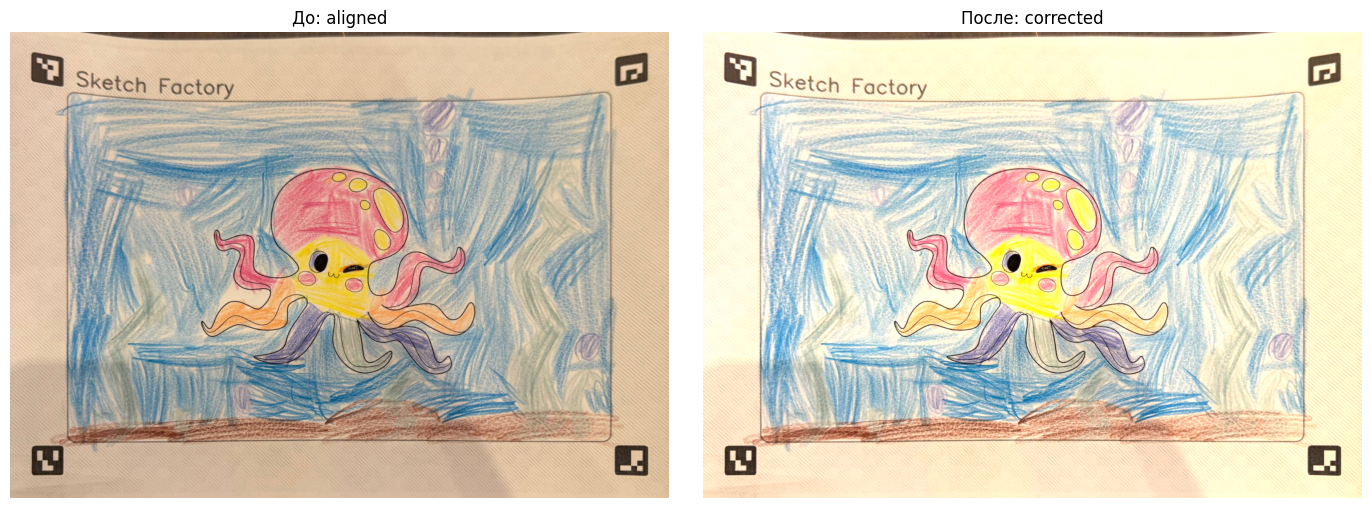

In [2]:
aligned = cv2.imread(str(ALIGNED_PATH))
image_rect = image_rect_from_svg(str(SVG_PATH), CONTENT_SCALE)

# correct_photo ещё принимает meta — даём минимум пока не почистили
meta = {"drawing_bbox": list(DRAWING_BBOX)}
corrected, info = correct_photo(aligned, image_rect, meta=meta)

print(f"paper_bgr: {info['paper_bgr'].astype(int).tolist()} -> target [240, 240, 240]")
print(f"gain_bgr:  {info['gain_bgr'].round(2).tolist()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(cv2.cvtColor(aligned, cv2.COLOR_BGR2RGB))
axes[0].axis("off"); axes[0].set_title("До: aligned")
axes[1].imshow(cv2.cvtColor(corrected, cv2.COLOR_BGR2RGB))
axes[1].axis("off"); axes[1].set_title("После: corrected")
plt.tight_layout(); plt.show()

In [3]:
out_path = OUTPUT_DIR / f"stage3_corrected_{STEM}.png"
cv2.imwrite(str(out_path), corrected)
print(f"Сохранено: {out_path}")


Сохранено: C:\Users\Luga\Documents\GitHub\ink-to-motion\dev\pipeline\output\stage3_corrected_003_test3.png
